# **SSL using Combined Data and DS2 for down stream with Physical Sensors only**

In [ ]:
import gc
import math
import torch
from torch.utils.data import DataLoader, ConcatDataset
import optuna
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

from preprocessing import CMAPSSWindowed, preprocessing
from dataloading import load_data
from Models import (
    TCNBackbone, TransformerBackbone, TCNTransformerBackbone,
    MaskedReconstructionSSL, RULHead, BinaryClassificationHead,
    init_inducing_points, EarlyStopping,
)
from Training import train_ssl, train_rul, train_cls
from Testing import test_rul, test_cls
from plots import (
    plot_ssl_history, plot_ssl_reconstruction, plot_ssl_feature_errors,
    plot_metric_curve, plot_regression_dashboard, plot_classification_dashboard,
)


pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
pip install scikit-learn h5py optuna gpytorch

### GPU check

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.11.0+cu128
CUDA available: True
Current GPU: NVIDIA GeForce RTX 4060 Ti
Using device: cuda


### Config

In [ ]:
DATA_DIR = "../../data_set"

SSL_FILES = [f"{DATA_DIR}/N-CMAPSS_DS01-005.h5", f"{DATA_DIR}/N-CMAPSS_DS03-012.h5", f"{DATA_DIR}/N-CMAPSS_DS04.h5",f"{DATA_DIR}/N-CMAPSS_DS05.h5", f"{DATA_DIR}/N-CMAPSS_DS06.h5", 
             f"{DATA_DIR}/N-CMAPSS_DS07.h5", f"{DATA_DIR}/N-CMAPSS_DS08c-008.h5", f"{DATA_DIR}/N-CMAPSS_DS08a-009.h5"]
RUL_FILE = f"{DATA_DIR}/N-CMAPSS_DS02-006.h5"

VAL_UNIT = 18  # held out from DS02's 6 training units for validation/early-stopping/Optuna

SSL_CHECKPOINT = "AllData_best_ssl_backbone_physical.pt"
RUL_CHECKPOINT = "AllData_best_rul_gp_head_physical.pt"
CLS_CHECKPOINT = "AllData_best_cls_gp_head_physical.pt"


## Data preprocessing


In [ ]:
def load_and_scale(filenames):

    train_dfs, val_dfs, feats = [], [], None
    for filename in filenames:
        W_var, X_s_var, X_v_var, T_var, A_var, train_df, test_df = load_data(filename)
        if feats is None:
            feats = W_var + X_s_var
            print(f"Using {len(feats)} features:", feats)

        train_scaled, val_scaled, _, _ = preprocessing(True, train_df, test_df, feats)
        del train_df, test_df
        gc.collect()
        train_dfs.append(train_scaled)
        val_dfs.append(val_scaled)
    return feats, train_dfs, val_dfs


features, ssl_train_dfs, ssl_val_dfs = load_and_scale(SSL_FILES)


def build_ssl_datasets(window_size, stride):
    train_sets = [CMAPSSWindowed(df, features, window_size, stride, has_target=False) for df in ssl_train_dfs]
    val_sets = [CMAPSSWindowed(df, features, window_size, stride, has_target=False) for df in ssl_val_dfs]
    return ConcatDataset(train_sets), ConcatDataset(val_sets)



Operation time (min):  0.03619791666666667

W_dev shape: (4906636, 4) | W_test shape: (2735232, 4)
X_s_dev shape: (4906636, 14) | X_s_test shape: (2735232, 14)
X_v_dev shape: (4906636, 14) | X_v_test shape: (2735232, 14)
A_dev shape: (4906636, 4) | A_test shape: (2735232, 4)
Using 18 features: [np.str_('alt'), np.str_('Mach'), np.str_('TRA'), np.str_('T2'), np.str_('T24'), np.str_('T30'), np.str_('T48'), np.str_('T50'), np.str_('P15'), np.str_('P2'), np.str_('P21'), np.str_('P24'), np.str_('Ps30'), np.str_('P40'), np.str_('P50'), np.str_('Nf'), np.str_('Nc'), np.str_('Wf')]
Data Normalization


Operation time (min):  0.04401041666666667

W_dev shape: (5571277, 4) | W_test shape: (4251560, 4)
X_s_dev shape: (5571277, 14) | X_s_test shape: (4251560, 14)
X_v_dev shape: (5571277, 14) | X_v_test shape: (4251560, 14)
A_dev shape: (5571277, 4) | A_test shape: (4251560, 4)
Data Normalization


Operation time (min):  0.04583333333333333

W_dev shape: (6377452, 4) | W_test shape: (3602561, 4)
X

In [5]:
print(type(ssl_train_dfs), len(ssl_train_dfs))
for i, df in enumerate(ssl_train_dfs):
    print(i, df.shape, sorted(df['unit'].unique()))

<class 'list'> 8
0 (4906636, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
1 (5571277, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
2 (6377452, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
3 (4350606, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
4 (4257209, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
5 (4350176, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
6 (4299918, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
7 (4885389, 22) [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [6]:
print(type(ssl_val_dfs), len(ssl_val_dfs))
for i, df in enumerate(ssl_val_dfs):
    print(i, df.shape, sorted(df['unit'].unique()))

<class 'list'> 8
0 (2735232, 22) [np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
1 (4251560, 22) [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
2 (3602561, 22) [np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
3 (2562046, 22) [np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
4 (2522447, 22) [np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
5 (2869786, 22) [np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
6 (2117819, 22) [np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
7 (3722997, 22) [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


### Backbone builder


In [ ]:
def build_backbone(trial, num_features):
    backbone_type = trial.suggest_categorical("backbone_type", ["tcn", "transformer", "tcn_transformer"])
    dropout = trial.suggest_float("dropout", 0.0, 0.3)

    if backbone_type == "tcn":
        ch = trial.suggest_categorical("tcn_channels", [32, 64, 128])
        backbone = TCNBackbone(num_features=num_features, num_channels=(ch, ch, ch), dropout=dropout)

    elif backbone_type == "transformer":
        d_model = trial.suggest_categorical("tf_d_model", [32, 64, 128])
        nhead = trial.suggest_categorical("tf_nhead", [2, 4, 8])
        if d_model % nhead != 0:
            raise optuna.TrialPruned()
        num_layers = trial.suggest_int("tf_num_layers", 1, 4)
        dim_feedforward = trial.suggest_categorical("tf_dim_feedforward", [64, 128, 256])
        backbone = TransformerBackbone(num_features=num_features, d_model=d_model, nhead=nhead,
                                       num_layers=num_layers, dim_feedforward=dim_feedforward, dropout=dropout)

    else:
        ch = trial.suggest_categorical("hyb_tcn_channels", [32, 64])
        d_model = trial.suggest_categorical("hyb_d_model", [32, 64, 128])
        nhead = trial.suggest_categorical("hyb_nhead", [2, 4, 8])
        if d_model % nhead != 0:
            raise optuna.TrialPruned()
        num_layers = trial.suggest_int("hyb_num_layers", 1, 3)
        dim_feedforward = trial.suggest_categorical("hyb_dim_feedforward", [64, 128, 256])
        backbone = TCNTransformerBackbone(num_features=num_features, num_channels=(ch, ch), dropout=dropout,
                                          d_model=d_model, nhead=nhead, num_layers=num_layers,
                                          dim_feedforward=dim_feedforward)
    return backbone


def load_pretrained_backbone(backbone, checkpoint_path, device, freeze=False):

    state_dict = torch.load(checkpoint_path, map_location=device)
    backbone_state = {k[len("backbone."):]: v for k, v in state_dict.items() if k.startswith("backbone.")}
    backbone.load_state_dict(backbone_state)
    if freeze:
        for p in backbone.parameters():
            p.requires_grad = False
    return backbone


## Study 1: preprocessing + backbone + SSL pretraining



In [ ]:
SSL_space = [
    {"name": "large",  "d_model": 256, "n_head": 64, "dim_feedforward": 512, "ch_dim": 256, "dropout": 0.3},
    {"name": "medium", "d_model": 128, "n_head": 32, "dim_feedforward": 256, "ch_dim": 128, "dropout": 0.25},
    {"name": "light", "d_model": 64,  "n_head": 16,  "dim_feedforward": 128, "ch_dim": 64,  "dropout": 0.2},
]

SSL_SEARCH_EPOCHS = 8
SSL_FINAL_EPOCHS = 50

def ssl_objective(trial):
    arch_idx = trial.suggest_categorical("arch", [0, 1, 2])
    arch = SSL_space[arch_idx]

    window_size = trial.suggest_categorical("window_size", [50, 100, 500])
    stride_ratio = trial.suggest_categorical("stride_ratio", [0.3, 0.4])
    stride = int(window_size * stride_ratio)
    num_layers = trial.suggest_int("tf_num_layers", 1, 4) 
    mask_ratio = trial.suggest_categorical("mask_ratio", [0.40 ,0.50])
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    train_set, val_set = build_ssl_datasets(window_size, stride)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    backbone = TCNTransformerBackbone(
        num_features=len(features),
        num_layers= num_layers,
        num_channels=(arch["ch_dim"], arch["ch_dim"]),
        dropout=arch["dropout"],
        d_model=arch["d_model"],
        nhead=arch["n_head"],
        dim_feedforward=arch["dim_feedforward"],
    ).to(device)

    ssl_model = MaskedReconstructionSSL(
        backbone, backbone.d_model, len(features), mask_ratio=mask_ratio
    ).to(device)

    optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=lr, weight_decay=weight_decay)

    print(f"=============================== ssl_search_trial{trial.number} =================================")
    print(backbone)
    print(f"arch: {arch['name']} (d_model={arch['d_model']}, nhead={arch['n_head']}, "
          f"ff={arch['dim_feedforward']}, ch={arch['ch_dim']}, dropout={arch['dropout']})")
    print(f"window={window_size}, stride={stride}, mask_ratio={mask_ratio:.3f}, "
          f"lr={lr:.2e}, wd={weight_decay:.2e}, batch={batch_size}")

    train_loss, train_mae, val_loss, val_mae, total_time, history = train_ssl(
        ssl_model, train_loader, val_loader, optimizer,
        epochs=SSL_SEARCH_EPOCHS, device=device,
        model_name=f"ssl_search_trial{trial.number}",
    )

    del train_set, val_set, train_loader, val_loader, ssl_model, backbone, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if not math.isfinite(val_loss):
        raise optuna.TrialPruned()

    return val_loss


study_ssl = optuna.create_study(
    
    direction="minimize",
    study_name="ssl_all_data_physical_sensors",
)
study_ssl.optimize(ssl_objective, n_trials=10)

print("Best SSL trial:", study_ssl.best_trial.number)
print("Best params:", study_ssl.best_params)
print("Best arch:", SSL_space[study_ssl.best_params["arch"]])
print("Best val masked-MSE:", study_ssl.best_value)

=============================== ssl_search_trial0 =================================
TCNTransformerBackbone(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(18, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(18, 64, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (relu): ReLU()
    )
 

### Final SSL retrain with the winning Study 1 config

In [9]:
best_ssl = {
    'window_size': 50,
    'stride_ratio': 0.4,
    'mask_ratio': 0.4,
    'lr': 6.55e-04,
    'weight_decay': 1.35e-05,
    'batch_size': 64,
    'backbone_type': 'tcn_transformer',
    'dropout': 0.25,
    'hyb_tcn_channels': 128,
    'hyb_d_model': 128,
    'hyb_nhead': 32,
    'hyb_num_layers': 1,
    'hyb_dim_feedforward': 256,
}  # from optuna

In [7]:
SSL_FINAL_EPOCHS = 50

window_size = best_ssl["window_size"]
stride = int(window_size * best_ssl["stride_ratio"])

ssl_train_set, ssl_val_set = build_ssl_datasets(window_size, stride)
ssl_train_loader = DataLoader(ssl_train_set, batch_size=best_ssl["batch_size"], shuffle=True)
ssl_val_loader = DataLoader(ssl_val_set, batch_size=best_ssl["batch_size"], shuffle=False)

backbone = TCNTransformerBackbone(
    num_features=len(features),
    num_layers= best_ssl["hyb_num_layers"],
    num_channels=(best_ssl["hyb_tcn_channels"], best_ssl["hyb_tcn_channels"]),
    dropout=best_ssl["dropout"],
    d_model=best_ssl["hyb_d_model"],
    nhead=best_ssl["hyb_nhead"],
    dim_feedforward=best_ssl["hyb_dim_feedforward"],
).to(device)

ssl_model = MaskedReconstructionSSL(
    backbone, backbone.d_model, len(features), mask_ratio=best_ssl["mask_ratio"]
).to(device)
optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=best_ssl["lr"], weight_decay=best_ssl["weight_decay"])

train_loss, train_mae, val_loss, val_mae, total_time, ssl_history = train_ssl(
    ssl_model, ssl_train_loader, ssl_val_loader, optimizer, epochs=SSL_FINAL_EPOCHS, device=device,
    model_name=SSL_CHECKPOINT[:-len(".pt")],
)
print(f"Final SSL backbone trained in {total_time:.1f}s -> saved to {SSL_CHECKPOINT}")


[SSL] Epoch 1 | train_mse=0.00038 train_mae=0.01174 | val_mse=0.00007 val_mae=0.00646 | epoch_time=274.01s val_time=42.77s
[SSL] Epoch 2 | train_mse=0.00005 train_mae=0.00549 | val_mse=0.00003 val_mae=0.00417 | epoch_time=222.71s val_time=40.28s
[SSL] Epoch 3 | train_mse=0.00003 train_mae=0.00439 | val_mse=0.00002 val_mae=0.00330 | epoch_time=224.86s val_time=41.07s
[SSL] Epoch 4 | train_mse=0.00003 train_mae=0.00387 | val_mse=0.00003 val_mae=0.00362 | epoch_time=223.52s val_time=39.94s
[SSL] Epoch 5 | train_mse=0.00002 train_mae=0.00354 | val_mse=0.00001 val_mae=0.00261 | epoch_time=223.64s val_time=40.18s
[SSL] Epoch 6 | train_mse=0.00002 train_mae=0.00332 | val_mse=0.00001 val_mae=0.00232 | epoch_time=226.41s val_time=41.38s
[SSL] Epoch 7 | train_mse=0.00002 train_mae=0.00315 | val_mse=0.00002 val_mae=0.00299 | epoch_time=222.31s val_time=40.75s
[SSL] Epoch 8 | train_mse=0.00002 train_mae=0.00301 | val_mse=0.00001 val_mae=0.00244 | epoch_time=223.79s val_time=40.36s
[SSL] Epoch 9 | 

### SSL plots

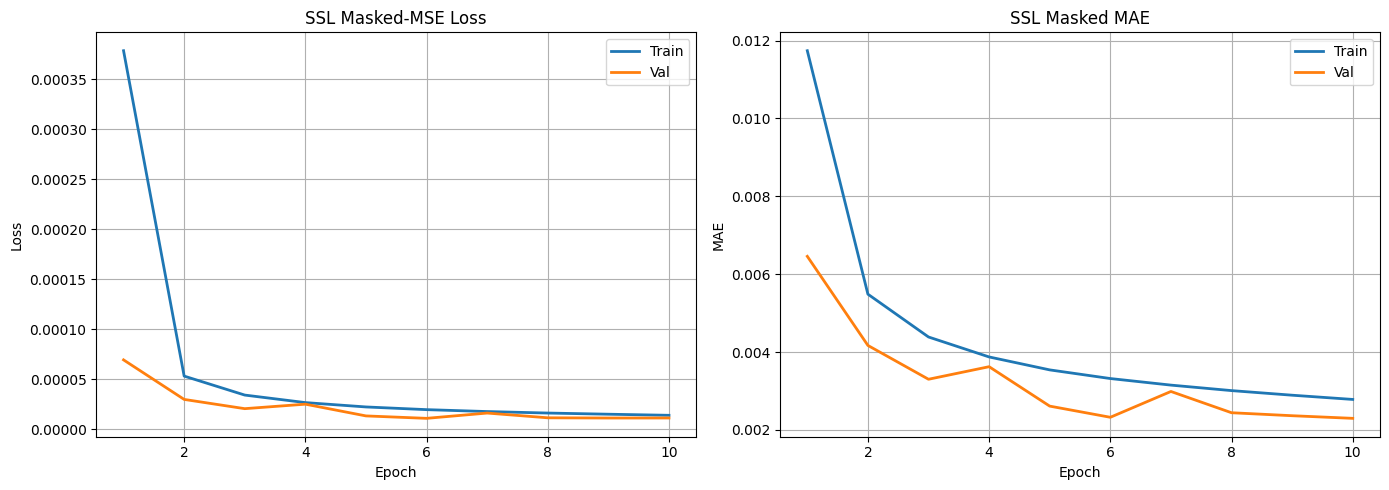

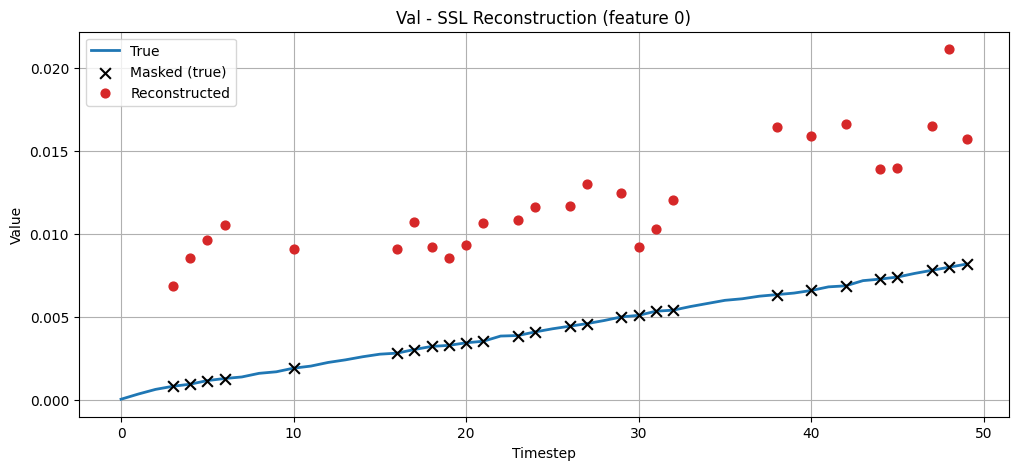

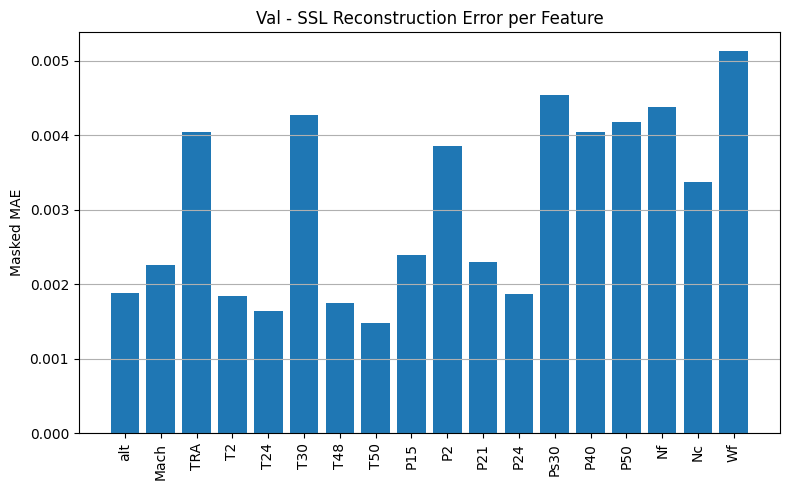

In [8]:
plot_ssl_history(ssl_history)

ssl_model.eval()
with torch.no_grad():
    x_batch = next(iter(ssl_val_loader)).to(device).float()
    pred_batch, mask_batch, _ = ssl_model(x_batch)

plot_ssl_reconstruction(x_batch[0], pred_batch[0], mask_batch[0], feature_idx=0, split_name="Val")
plot_ssl_feature_errors(x_batch, pred_batch, mask_batch, feature_names=features, split_name="Val")


## RUL data preprocessing (DS02)


In [ ]:
*_, ds02_train_df, ds02_test_df = load_data(RUL_FILE)
ds02_train_scaled, ds02_test_scaled, _, _ = preprocessing(True, ds02_train_df, ds02_test_df, features)
del ds02_train_df, ds02_test_df
gc.collect()

rul_train_df = ds02_train_scaled[ds02_train_scaled["unit"] != VAL_UNIT]
rul_val_df = ds02_train_scaled[ds02_train_scaled["unit"] == VAL_UNIT]

rul_train_set = CMAPSSWindowed(rul_train_df, features, window_size=50, stride=15, has_target=True) 
rul_val_set = CMAPSSWindowed(rul_val_df, features, window_size=50, stride=15, has_target=True)
rul_test_set = CMAPSSWindowed(ds02_test_scaled, features, window_size=50, stride=15, has_target=True)

print(f"RUL train windows: {len(rul_train_set)} | val windows: {len(rul_val_set)} | test windows: {len(rul_test_set)}")



Operation time (min):  0.027604166666666666

W_dev shape: (5263447, 4) | W_test shape: (1253743, 4)
X_s_dev shape: (5263447, 14) | X_s_test shape: (1253743, 14)
X_v_dev shape: (5263447, 14) | X_v_test shape: (1253743, 14)
A_dev shape: (5263447, 4) | A_test shape: (1253743, 4)
Data Normalization

RUL train windows: 291501 | val windows: 59378 | test windows: 83574


## Study 2: RUL GP head


In [ ]:
RUL_SEARCH_EPOCHS = 10

window_size = best_ssl["window_size"]
stride = int(window_size * best_ssl["stride_ratio"])

def rul_objective(trial):
    num_inducing = trial.suggest_categorical("num_inducing", [100, 200, 400, 1000]) 
    batch_size = trial.suggest_categorical("rul_batch_size", [32, 64, 128])
    lr = trial.suggest_float("rul_lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("rul_weight_decay", 1e-6, 1e-3, log=True)
    freeze = trial.suggest_categorical("freeze_backbone", [True, False])

    train_loader = DataLoader(rul_train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(rul_val_set, batch_size=batch_size, shuffle=False)

    #trial_backbone = build_backbone(optuna.trial.FixedTrial(best_ssl), num_features=len(features)).to(device)
    
    trial_backbone = TCNTransformerBackbone(
        num_features=len(features),
        num_layers= best_ssl["hyb_num_layers"],
        num_channels=(best_ssl["hyb_tcn_channels"], best_ssl["hyb_tcn_channels"]),
        dropout=best_ssl["dropout"],
        d_model=best_ssl["hyb_d_model"],
        nhead=best_ssl["hyb_nhead"],
        dim_feedforward=best_ssl["hyb_dim_feedforward"],
        ).to(device)
    
    load_pretrained_backbone(trial_backbone, SSL_CHECKPOINT, device, freeze=freeze)

    inducing_points = init_inducing_points(trial_backbone, train_loader, device, num_inducing=num_inducing)
    model = RULHead(trial_backbone, trial_backbone.d_model, inducing_points=inducing_points).to(device)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay
    )

    print(f"=============================== trial{trial.number} =================================")
    print(trial_backbone)
    print(f"num_inducing: {num_inducing}, freeze: {freeze}, LR: {lr}, Weight Decay: {weight_decay}, Batch Size: {batch_size}, dimension: {trial_backbone.d_model}")
    for _ in range(RUL_SEARCH_EPOCHS):
        train_rul(model, train_loader, optimizer, device)
    val_metrics = test_rul(model, val_loader, device)

    if not math.isfinite(val_metrics["rmse"]):
 
        del model, trial_backbone, optimizer, train_loader, val_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        raise optuna.TrialPruned()

    del model, trial_backbone, optimizer, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return val_metrics["rmse"]


study_rul = optuna.create_study(direction="minimize", study_name="rul_physical_sensors")
study_rul.optimize(rul_objective, n_trials=15)

print("Best RUL trial:", study_rul.best_trial.number)
print("Best params:", study_rul.best_params)
print("Best val RMSE:", study_rul.best_value)


=============================== trial0 =================================
TCNTransformerBackbone(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(18, 128, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.25, inplace=False)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.25, inplace=False)
      (downsample): Conv1d(18, 128, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.25, inplace=False)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.25, inplace=False)
      (relu): ReLU()
    )


### Final RUL retrain with the winning Study 2 config

In [ ]:
best_rul = {'num_inducing': 400,
            'rul_batch_size': 32, 
            'rul_lr': 0.000918464391820684, 
            'rul_weight_decay': 5.407801641555121e-05, 
            'freeze_backbone': True
            } # best params are from optuna

In [ ]:
#best_rul = study_rul.best_params
RUL_FINAL_EPOCHS = 60

rul_train_loader = DataLoader(rul_train_set, batch_size=best_rul["rul_batch_size"], shuffle=True)
rul_val_loader = DataLoader(rul_val_set, batch_size=best_rul["rul_batch_size"], shuffle=False)

#rul_backbone = build_backbone(optuna.trial.FixedTrial(best_ssl), num_features=len(features)).to(device)

rul_backbone = TCNTransformerBackbone(
        num_features=len(features),
        num_layers= best_ssl["hyb_num_layers"],
        num_channels=(best_ssl["hyb_tcn_channels"], best_ssl["hyb_tcn_channels"]),
        dropout=best_ssl["dropout"],
        d_model=best_ssl["hyb_d_model"],
        nhead=best_ssl["hyb_nhead"],
        dim_feedforward=best_ssl["hyb_dim_feedforward"],
        ).to(device)
load_pretrained_backbone(rul_backbone, SSL_CHECKPOINT, device, freeze=best_rul["freeze_backbone"])

inducing_points = init_inducing_points(rul_backbone, rul_train_loader, device, num_inducing=best_rul["num_inducing"])
rul_model = RULHead(rul_backbone, rul_backbone.d_model, inducing_points=inducing_points).to(device)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, rul_model.parameters()),
    lr=best_rul["rul_lr"], weight_decay=best_rul["rul_weight_decay"]
)

early_stopper = EarlyStopping(patience=8, min_delta=1e-4, save_path=RUL_CHECKPOINT)
rul_train_history, rul_val_history = [], []

for epoch in range(RUL_FINAL_EPOCHS):
    train_metrics = train_rul(rul_model, rul_train_loader, optimizer, device)
    val_metrics = test_rul(rul_model, rul_val_loader, device) 
    rul_train_history.append(train_metrics)
    rul_val_history.append(val_metrics)

    print(f"Epoch {epoch+1}/{RUL_FINAL_EPOCHS} | "
          f"train_loss={train_metrics['loss']:.4f} train_r2={train_metrics['r2']:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} val_rmse={val_metrics['rmse']:.4f} val_r2={val_metrics['r2']:.4f} | "
          f"time={train_metrics['time']:.2f}s")

    early_stopper(val_metrics["loss"], rul_model)
    if early_stopper.early_stop:
        print("Early stopping triggered")
        break

if early_stopper.has_saved:
    rul_model.load_state_dict(torch.load(early_stopper.save_path))
else:
    print(f"Warning: RUL head training never improved on the initial loss (likely diverged/NaN) - "
          f"no checkpoint was saved to {early_stopper.save_path}, keeping the last epoch's weights.")


[RUL Train] Loss: 123.2822 - RMSE: 17.6738 - NASA mean: 6.3387 - NASA total: 1847733.32 - Time: 120.26s
[RUL Test] Loss: 7.4387 - RMSE: 7.3820 - R2: 0.8739 - NASA mean: 0.8833 - NASA total: 52448.84 - Time: 9.67s
Epoch 1/60 | train_loss=123.2822 train_r2=0.3903 | val_loss=7.4387 val_rmse=7.3820 val_r2=0.8739 | time=120.26s
[RUL Train] Loss: 8.5693 - RMSE: 9.8778 - NASA mean: 1.3195 - NASA total: 384635.35 - Time: 118.93s
[RUL Test] Loss: 3.9234 - RMSE: 6.2280 - R2: 0.9102 - NASA mean: 0.6932 - NASA total: 41161.11 - Time: 9.80s
Epoch 2/60 | train_loss=8.5693 train_r2=0.8096 | val_loss=3.9234 val_rmse=6.2280 val_r2=0.9102 | time=118.93s
[RUL Train] Loss: 5.2991 - RMSE: 9.3449 - NASA mean: 1.1975 - NASA total: 349058.80 - Time: 119.32s
[RUL Test] Loss: 3.5592 - RMSE: 6.3526 - R2: 0.9066 - NASA mean: 0.6116 - NASA total: 36318.18 - Time: 9.56s
Epoch 3/60 | train_loss=5.2991 train_r2=0.8295 | val_loss=3.5592 val_rmse=6.3526 val_r2=0.9066 | time=119.32s
[RUL Train] Loss: 4.3930 - RMSE: 9.10

### RUL training curves

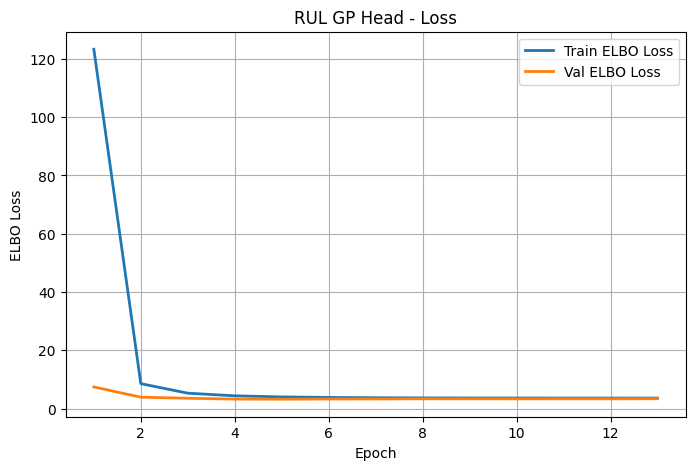

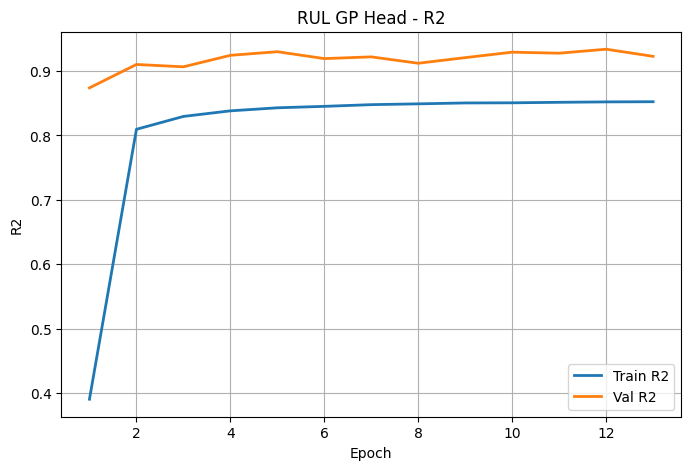

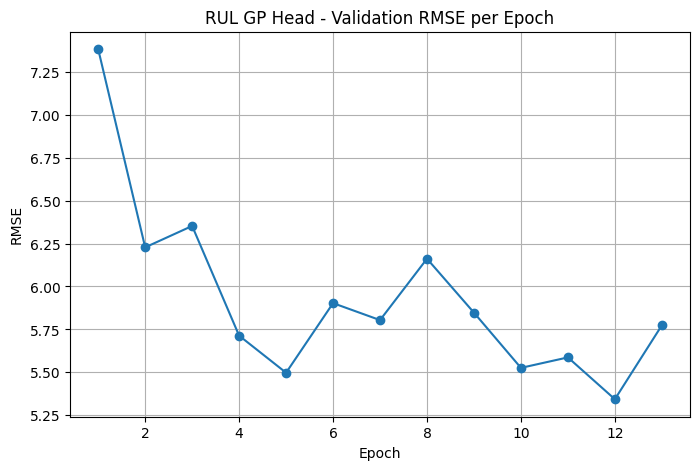

In [ ]:
plot_metric_curve([h["loss"] for h in rul_train_history], [h["loss"] for h in rul_val_history],
                   metric_name="ELBO Loss", title="RUL GP Head - Loss")
plot_metric_curve([h["r2"] for h in rul_train_history], [h["r2"] for h in rul_val_history],
                   metric_name="R2", title="RUL GP Head - R2")


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rul_val_history) + 1), [h["rmse"] for h in rul_val_history], marker="o")
plt.xlabel("Epoch"); plt.ylabel("RMSE")
plt.title("RUL GP Head - Validation RMSE per Epoch")
plt.grid(True)
plt.show()


## Final RUL test evaluation


In [13]:
rul_test_loader = DataLoader(rul_test_set, batch_size=best_rul["rul_batch_size"], shuffle=False)

[RUL Test] Loss: 3.9636 - RMSE: 8.9647 - R2: 0.7765 - NASA mean: 1.3601 - NASA total: 113673.05 - Time: 14.79s
{'loss': 3.963635868628211, 'rmse': 8.964723587036133, 'r2': 0.7765330672264099, 'nasa_mean': 1.360148453765525, 'nasa_total': 113673.046875, 'time': 14.789513111114502}
STD: 5.820929050445557


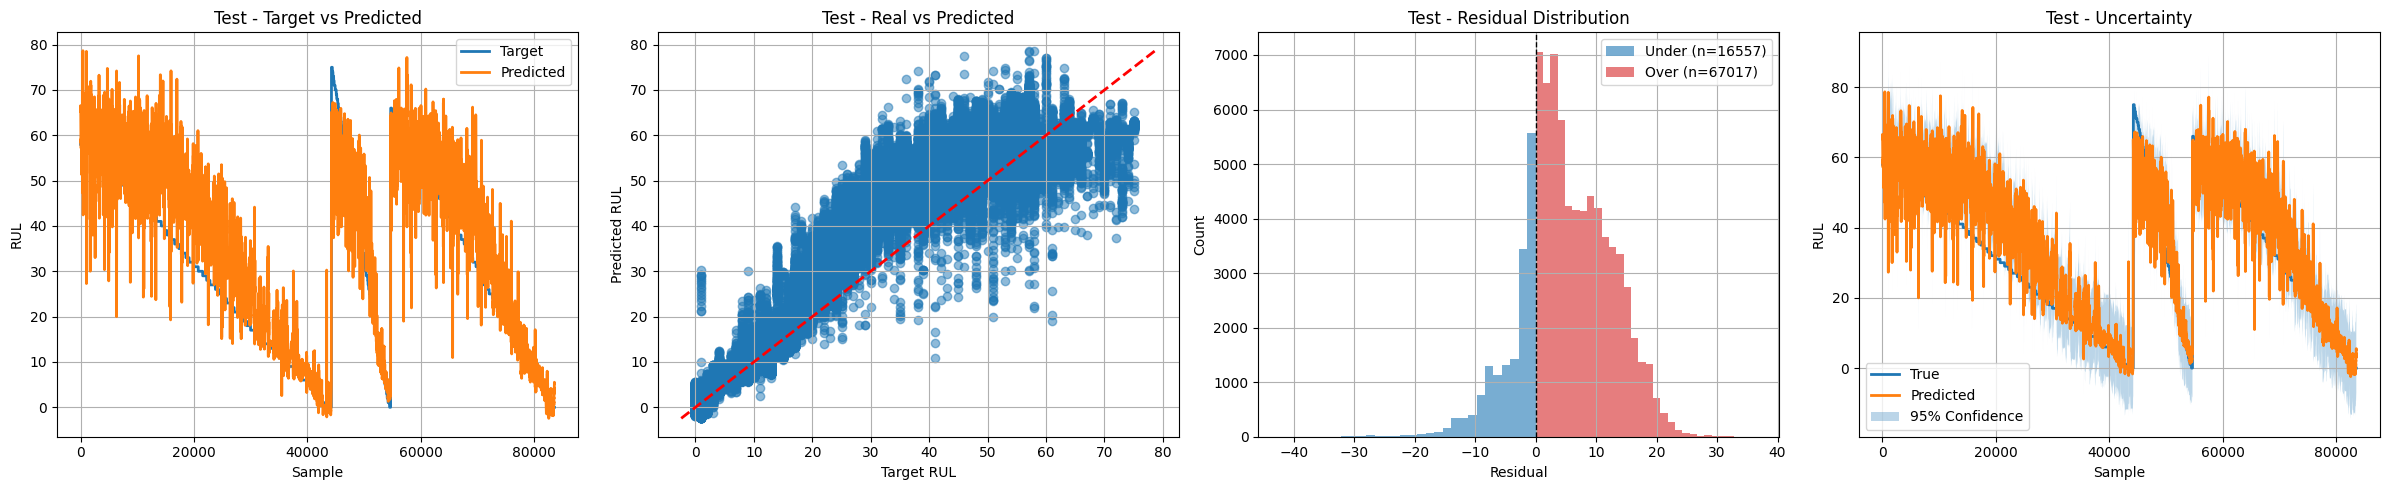

In [16]:
final_rul_metrics = test_rul(rul_model, rul_test_loader, device)

print({k: v for k, v in final_rul_metrics.items() if k not in ("preds", "targets", "std")})
print(f"STD: {final_rul_metrics['std'].mean()}")
plot_regression_dashboard(
    final_rul_metrics["targets"], final_rul_metrics["preds"],
    std=final_rul_metrics["std"], split_name="Test"
)


## Anomaly detection / classification head


In [ ]:
window_size =  50 
stride_ratio = 0.3 
stride = int(window_size * stride_ratio) 

cls_train_set = CMAPSSWindowed(rul_train_df, features, window_size, stride, has_target=True, target_col="hs")
cls_val_set = CMAPSSWindowed(rul_val_df, features, window_size, stride, has_target=True, target_col="hs")
cls_test_set = CMAPSSWindowed(ds02_test_scaled, features, window_size, stride, has_target=True, target_col="hs")

cls_train_loader = DataLoader(cls_train_set, batch_size=best_rul["rul_batch_size"], shuffle=True)
cls_val_loader = DataLoader(cls_val_set, batch_size=best_rul["rul_batch_size"], shuffle=False)
cls_test_loader = DataLoader(cls_test_set, batch_size=best_rul["rul_batch_size"], shuffle=False)

#cls_backbone = build_backbone(optuna.trial.FixedTrial(best_ssl), num_features=len(features)).to(device)
cls_backbone = TCNTransformerBackbone(
        num_features=len(features),
        num_layers= best_ssl["hyb_num_layers"],
        num_channels=(best_ssl["hyb_tcn_channels"], best_ssl["hyb_tcn_channels"]),
        dropout=best_ssl["dropout"],
        d_model=best_ssl["hyb_d_model"],
        nhead=best_ssl["hyb_nhead"],
        dim_feedforward=best_ssl["hyb_dim_feedforward"],
        ).to(device)

load_pretrained_backbone(cls_backbone, SSL_CHECKPOINT, device, freeze=best_rul["freeze_backbone"])

cls_inducing_points = init_inducing_points(
    cls_backbone, cls_train_loader, device, num_inducing=best_rul["num_inducing"]
)
cls_model = BinaryClassificationHead(cls_backbone, cls_backbone.d_model, inducing_points=cls_inducing_points).to(device)
cls_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cls_model.parameters()),
    lr=best_rul["rul_lr"], weight_decay=best_rul["rul_weight_decay"]
)


[CLS Train] Loss: 0.3461 - Time: 134.67s
[CLS Test] Loss: 0.2742 - Accuracy: 0.8683 - F1: 0.6303 - Precision: 0.8058 - Recall: 0.5176 - AUROC: 0.9380 - Brier: 0.0888 - ECE: 0.0263 - Time: 11.51s
Epoch 1/40 | train_loss=0.3461 | val_loss=0.2742 acc=0.8683 f1=0.6303 ece=0.0263 time=134.67s
[CLS Train] Loss: 0.3021 - Time: 131.78s
[CLS Test] Loss: 0.2461 - Accuracy: 0.8914 - F1: 0.7282 - Precision: 0.7970 - Recall: 0.6703 - AUROC: 0.9576 - Brier: 0.0761 - ECE: 0.0445 - Time: 11.96s
Epoch 2/40 | train_loss=0.3021 | val_loss=0.2461 acc=0.8914 f1=0.7282 ece=0.0445 time=131.78s
[CLS Train] Loss: 0.2985 - Time: 135.04s
[CLS Test] Loss: 0.2425 - Accuracy: 0.9040 - F1: 0.7581 - Precision: 0.8362 - Recall: 0.6934 - AUROC: 0.9613 - Brier: 0.0745 - ECE: 0.0550 - Time: 12.17s
Epoch 3/40 | train_loss=0.2985 | val_loss=0.2425 acc=0.9040 f1=0.7581 ece=0.0550 time=135.04s
[CLS Train] Loss: 0.2966 - Time: 130.41s
[CLS Test] Loss: 0.2352 - Accuracy: 0.8900 - F1: 0.7264 - Precision: 0.7890 - Recall: 0.6729

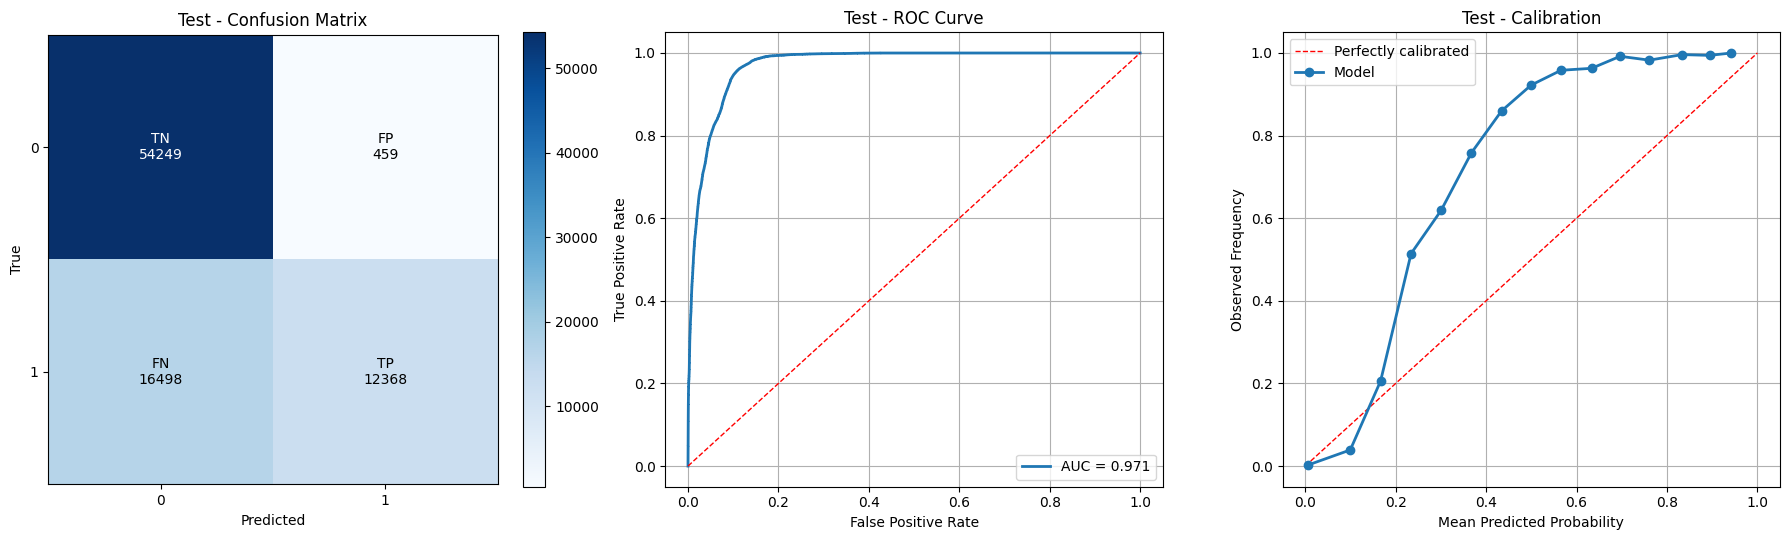

In [19]:
CLS_EPOCHS = 40
cls_early_stopper = EarlyStopping(patience=8, min_delta=1e-4, save_path=CLS_CHECKPOINT)

for epoch in range(CLS_EPOCHS):
    train_metrics = train_cls(cls_model, cls_train_loader, cls_optimizer, device)
    val_metrics = test_cls(cls_model, cls_val_loader, device)

    print(f"Epoch {epoch+1}/{CLS_EPOCHS} | train_loss={train_metrics['loss']:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} "
          f"f1={val_metrics['f1']:.4f} ece={val_metrics['ece']:.4f} time={train_metrics['time']:.2f}s")

    cls_early_stopper(val_metrics["loss"], cls_model)
    if cls_early_stopper.early_stop:
        print("Early stopping triggered")
        break

if cls_early_stopper.has_saved:
    cls_model.load_state_dict(torch.load(cls_early_stopper.save_path))
else:
    print(f"Warning: classification head training never improved on the initial loss (likely diverged/NaN) - "
          f"no checkpoint was saved to {cls_early_stopper.save_path}, keeping the last epoch's weights.")

final_cls_metrics = test_cls(cls_model, cls_test_loader, device)
print({k: v for k, v in final_cls_metrics.items() if k not in ("probs", "targets")})

plot_classification_dashboard(final_cls_metrics["targets"], final_cls_metrics["probs"], split_name="Test")
